# Laboration 2: Modelling Wine Quality

**Name(s):**
**Date:**

Follow `instructions.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Sections below are labelled to match the instructions exactly
(Step 1 / Step 2 / Step 3 / Step 4) so you can move through the 4-hour
session without hunting for where each part goes.

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, classification_report)

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42  # keep this fixed so your results are reproducible


---
## Step 1 — Data Curation (0:00–0:30)

- [ ] Load the data, check shape / columns / dtypes
- [ ] Check for missing values
- [ ] Check for duplicate rows — look closely before deciding what to do (→ **Checkpoint 1a**)
- [ ] Look at the distribution of `quality` (→ **Checkpoint 1b**)
- [ ] Standardise the 11 predictor variables, ready for Step 2

In [139]:
# Load the data (red wine is the primary dataset for Steps 1-3)

# Download the files from github if you are working on uppmax/colab
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv

df_red = pd.read_csv('winequality-red.csv', sep=';')
df_red.head()

--2026-09-21 13:49:56--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84199 (82K) [text/plain]
Saving to: ‘winequality-red.csv.4’

winequality-red.csv 100%[===================>]  82.23K  --.-KB/s    in 0.006s  

2026-09-21 13:49:57 (13.8 MB/s) - ‘winequality-red.csv.4’ saved [84199/84199]

--2026-09-21 13:49:57--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [140]:
# TODO: check the shape, column names, and dtypes
print('\nred_wine quality shape', df_red.shape)
print('\nred_wine quality columns', df_red.columns)
print('\nColumn dtypes:')
print(df_red.dtypes)


red_wine quality shape (1599, 12)

red_wine quality columns Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Column dtypes:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [141]:
# TODO: check for missing values
print('Missing value counts:')
print(df_red.isnull())

Missing value counts:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0             False             False        False           False      False   
1             False             False        False           False      False   
2             False             False        False           False      False   
3             False             False        False           False      False   
4             False             False        False           False      False   
...             ...               ...          ...             ...        ...   
1594          False             False        False           False      False   
1595          False             False        False           False      False   
1596          False             False        False           False      False   
1597          False             False        False           False      False   
1598          False             False        False           False      False   

     

In [142]:
# TODO: check for duplicate rows (df_red.duplicated())
print(df_red.duplicated())
print('\nDuplicate rows:')
print(df_red[df_red.duplicated()])
print('\nTotal number of duplicate rows:')
print(df_red.duplicated().sum())
# How many are there? What will you do about them, and why?
# Removing duplicates
df_red = df_red.drop_duplicates()
print('\nNumber of duplicate rows after removing duplicates:')
print(df_red.duplicated().sum())
# -- write your reasoning on the answer sheet (Checkpoint 1a), not here

0       False
1       False
2       False
3       False
4        True
        ...  
1594    False
1595    False
1596     True
1597    False
1598    False
Length: 1599, dtype: bool

Duplicate rows:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4               7.4             0.700         0.00            1.90      0.076   
11              7.5             0.500         0.36            6.10      0.071   
27              7.9             0.430         0.21            1.60      0.106   
40              7.3             0.450         0.36            5.90      0.074   
65              7.2             0.725         0.05            4.65      0.086   
...             ...               ...          ...             ...        ...   
1563            7.2             0.695         0.13            2.00      0.076   
1564            7.2             0.695         0.13            2.00      0.076   
1567            7.2             0.695         0.13            2.00      0.

In [143]:
# TODO: look at the distribution of `quality`
# (value_counts() and/or a histogram are both fine)

print('Distribution of quality:')
print(df_red['quality'].value_counts())

Distribution of quality:
quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64


In [144]:
# TODO: separate predictors (X, the 11 physicochemical columns) from the
# response (y = quality), then standardise X ready for PCA.
y_red = df_red['quality']
x_red = df_red.drop('quality', axis=1)
x_scaled_red = StandardScaler().fit_transform(x_red)
x_red
# Hint: StandardScaler().fit_transform(X) -- do NOT standardise quality itself.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


---
## Step 2 — PCA (0:30–1:30)

Fit PCA on the **standardised predictors only** — `quality` is the response
you are trying to predict, not a predictor, so it must not go into the PCA.

- [ ] Fit PCA, produce a scree plot (individual + cumulative variance)
- [ ] Decide how many components to keep, and by which criterion (→ **Checkpoint 2a**)
- [ ] Score plot (PC1 vs PC2), coloured by `quality` (→ **Checkpoint 2b**)
- [ ] Loading plot for the same two components (→ **Checkpoint 2c**)

In [145]:
# TODO: fit PCA on the standardised predictor matrix
pca_sklearn_red = PCA()
scores_sklearn_red = pca_sklearn_red.fit_transform(x_scaled_red)
print(pca_sklearn_red.explained_variance_ratio_.round(3))

[0.283 0.173 0.141 0.114 0.087 0.058 0.053 0.037 0.031 0.016 0.005]


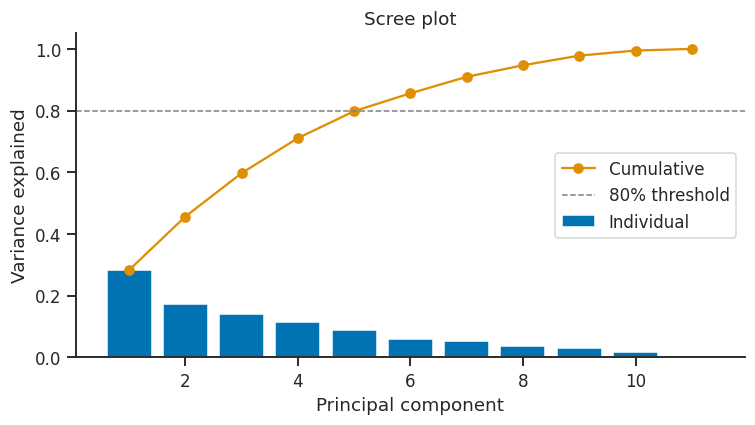

In [146]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks
fig, ax = plt.subplots(figsize=(7, 4))
n_show = 11
ax.bar(range(1, n_show+1), pca_sklearn_red.explained_variance_ratio_[:n_show],
       color=sns.color_palette('colorblind')[0], label='Individual')
ax.plot(range(1, n_show+1), np.cumsum(pca_sklearn_red.explained_variance_ratio_[:n_show]),
        'o-', color=sns.color_palette('colorblind')[1], label='Cumulative')
ax.axhline(0.80, color='gray', ls='--', lw=1, label='80% threshold')
ax.set_xlabel('Principal component'); ax.set_ylabel('Variance explained')
ax.set_title('Scree plot')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

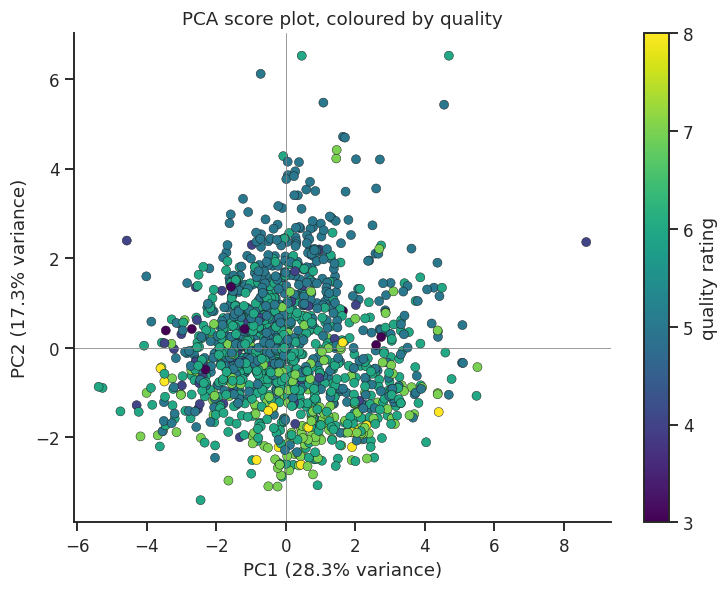

In [147]:
# TODO: score plot -- PC1 vs PC2, colour the points by `quality`
# (a continuous colourmap, e.g. cmap='viridis', works well for an ordinal 0-10 score)
df_scores_red = pd.DataFrame(scores_sklearn_red[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_scores_red['quality'] = df_red['quality'].values

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(df_scores_red['PC1'], df_scores_red['PC2'], c=df_scores_red['quality'],
                 cmap='viridis', s=35, edgecolor='k', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca_sklearn_red.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_sklearn_red.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA score plot, coloured by quality')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.colorbar(sc, label='quality rating')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

                       PC1   PC2
pH                   -0.44  0.00
volatile acidity     -0.24  0.28
alcohol              -0.12 -0.40
free sulfur dioxide  -0.02  0.51
total sulfur dioxide  0.04  0.58
residual sugar        0.13  0.24
chlorides             0.21  0.13
sulphates             0.25 -0.05
density               0.39  0.23
citric acid           0.46 -0.16
fixed acidity         0.49 -0.11


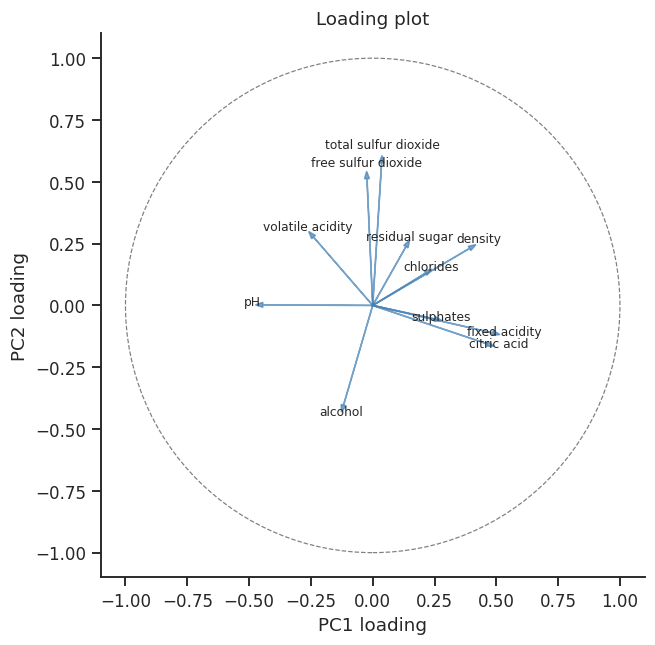

In [148]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?
loadings_df_red = pd.DataFrame(pca_sklearn_red.components_[:2].T, index=x_red.columns,
                            columns=['PC1', 'PC2'])
print(loadings_df_red.round(2).sort_values('PC1'))

fig, ax = plt.subplots(figsize=(7, 6))
for var_name in x_red.columns:
    x_coord, y_coord = loadings_df_red.loc[var_name, 'PC1'], loadings_df_red.loc[var_name, 'PC2']
    ax.arrow(0, 0, x_coord, y_coord, head_width=0.02, color='steelblue', alpha=0.7)
    ax.text(x_coord*1.1, y_coord*1.1, var_name, fontsize=8, ha='center')
circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', lw=0.8)
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1 loading'); ax.set_ylabel('PC2 loading')
ax.set_aspect('equal')
ax.set_title('Loading plot')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
## Step 3 — Model Quality: PLS *and* LDA (1:30–3:00)

Build **both** models today (see `instructions.md` for the full reasoning) —
not a choice between them. Keep both sections; do not delete either.

- [ ] Fit both models with a proper train/test split (or CV)
- [ ] Report validated performance for each, not training-set fit (→ **Checkpoints 3a, 3b**)
- [ ] Compare the two models (→ **Checkpoint 3c**)
- [ ] Identify which variable(s) matter most to each model (→ **Checkpoint 3d**)

### PLS (quality treated as continuous)

In [149]:
# TODO: train/test split (or set up cross-validation)
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(x_red, y_red, test_size=0.25, random_state=0)
print(f'Train: {X_train_red.shape[0]} spectra, Test: {X_test_red.shape[0]} spectra')

Train: 1019 spectra, Test: 340 spectra


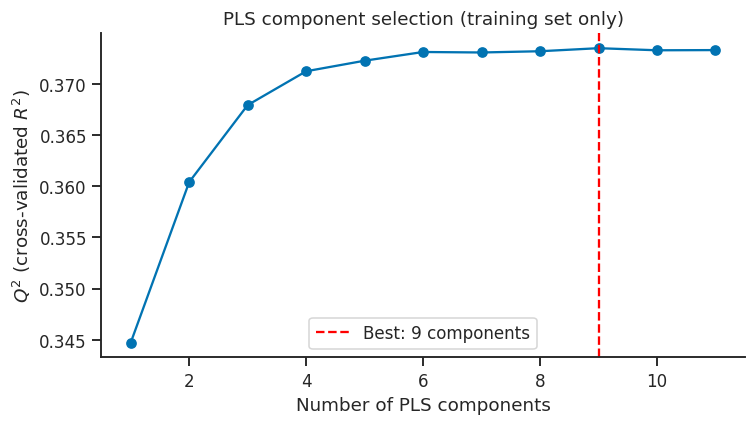

Selected 9 PLS components (Q2=0.373)


In [150]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone
kf = KFold(n_splits=10, shuffle=True, random_state=1)
max_components = 11
q2_scores_red = []
for nc in range(1, max_components + 1):
    pls = PLSRegression(n_components=nc, scale=True)
    y_cv_red = cross_val_predict(pls, X_train_red, y_train_red, cv=kf).ravel()
    q2_scores_red.append(r2_score(y_train_red, y_cv_red))

best_nc_red = np.argmax(q2_scores_red) + 1
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, max_components+1), q2_scores_red, 'o-', color=sns.color_palette('colorblind')[0])
ax.axvline(best_nc_red, color='red', ls='--', label=f'Best: {best_nc_red} components')
ax.set_xlabel('Number of PLS components'); ax.set_ylabel('$Q^2$ (cross-validated $R^2$)')
ax.set_title('PLS component selection (training set only)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
print(f'Selected {best_nc_red} PLS components (Q2={q2_scores_red[best_nc_red-1]:.3f})')

PLS test-set R2:   0.259
PLS test-set RMSE: 0.724 mS/cm


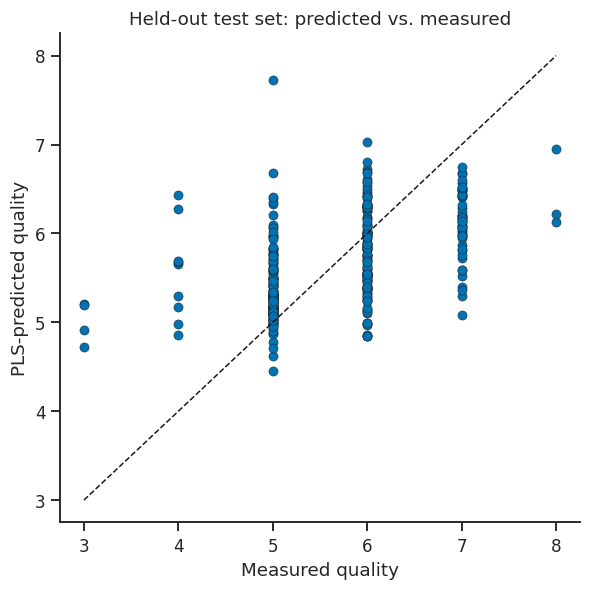

In [170]:
# TODO: report test-set RMSE and/or R^2, and a predicted-vs-observed plot
# (include the y=x identity line for reference)
pls_final_red = PLSRegression(n_components=best_nc_red, scale=True).fit(X_train_red, y_train_red)
y_pred_test_red = pls_final_red.predict(X_test_red).ravel()
r2_test_red = r2_score(y_test_red, y_pred_test_red)
rmse_test_red = np.sqrt(mean_squared_error(y_test_red, y_pred_test_red))
print(f'PLS test-set R2:   {r2_test_red:.3f}')
print(f'PLS test-set RMSE: {rmse_test_red:.3f} mS/cm')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test_red, y_pred_test_red, color=sns.color_palette('colorblind')[0], edgecolor='k', linewidth=0.3)
lims_red = [min(y_test_red.min(), y_pred_test_red.min()), max(y_test_red.max(), y_pred_test_red.max())]
ax.plot(lims_red, lims_red, 'k--', lw=1)
ax.set_xlabel('Measured quality'); ax.set_ylabel('PLS-predicted quality')
ax.set_title('Held-out test set: predicted vs. measured')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### LDA (quality binned into categories)

In [152]:
# TODO: define your quality bins explicitly here (e.g. low / medium / high).
# State your bin edges and reasoning on the answer sheet (Checkpoint 3b) --
# this is a real modelling decision, not a formality.
# Check the resulting class sizes: are they balanced?

labels_red = []

for yi in (y_red):
    if yi in (3,4):
        labels_red.append('low')
    elif yi in (5,6):
        labels_red.append('medium')
    else:
        labels_red.append('high')

In [153]:
# TODO: train/test split, then fit LinearDiscriminantAnalysis
class_names = ['low', 'medium', 'high']

X_train_lda_red, X_test_lda_red, y_train_lda_red, y_test_lda_red = train_test_split(
    x_scaled_red, labels_red, test_size=0.25, random_state=RANDOM_STATE, stratify=labels_red
)

lda_red = LinearDiscriminantAnalysis()
lda_red.fit(X_train_lda_red, y_train_lda_red)

LinearDiscriminantAnalysis()

Classification report (on test data):
              precision    recall  f1-score   support

         low       0.59      0.37      0.45        46
      medium       0.50      0.19      0.27        16
        high       0.86      0.95      0.90       278

    accuracy                           0.83       340
   macro avg       0.65      0.50      0.54       340
weighted avg       0.81      0.83      0.81       340



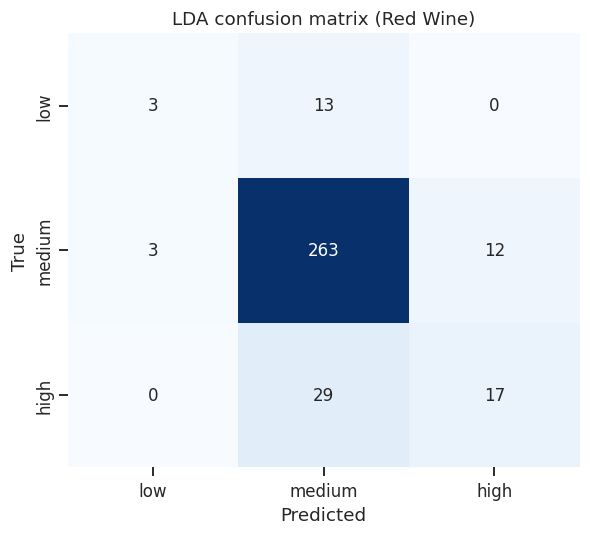

In [154]:
y_pred_lda_red = lda_red.predict(X_test_lda_red)

print('Classification report (on test data):')
print(classification_report(y_test_lda_red, y_pred_lda_red, target_names=class_names))

cm_red = confusion_matrix(y_test_lda_red, y_pred_lda_red, labels=class_names)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm_red, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=ax, cbar=False)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('LDA confusion matrix (Red Wine)')
plt.tight_layout()
plt.show()

In [155]:
# TODO: Checkpoint 3c/3d groundwork -- pull out and compare the top
# variables from both models (PLS coefficients vs. LDA discriminant
# loadings). Your written comparison goes on the answer sheet.

variable_names_red = x_red.columns

lda_variables_red = lda_red.coef_
lda_top_red = pd.DataFrame({
    'Variable': variable_names_red,
    'Loading': lda_variables_red[0]
}).sort_values('Loading', ascending=False)

print("Top LDA variables (Red Wine):")
print(lda_top_red.head(10).to_string(index=False))

pls_variables_red = pls_final_red.coef_

pls_top_red = pd.DataFrame({
    'Variable': variable_names_red,
    'Loading': pls_variables_red.flatten()
}).sort_values('Loading', ascending=False)

print("\nTop PLS variables (Red Wine):")
print(pls_top_red.head(10).to_string(index=False))

Top LDA variables (Red Wine):
            Variable   Loading
             alcohol  0.803324
       fixed acidity  0.784384
           sulphates  0.625692
      residual sugar  0.379542
                  pH  0.137224
         citric acid  0.079064
total sulfur dioxide -0.061459
 free sulfur dioxide -0.146983
    volatile acidity -0.298881
           chlorides -0.306551

Top PLS variables (Red Wine):
            Variable   Loading
           sulphates  0.979822
             alcohol  0.312729
      residual sugar  0.036912
       fixed acidity  0.029164
 free sulfur dioxide  0.001785
total sulfur dioxide -0.002551
         citric acid -0.395201
                  pH -0.525678
    volatile acidity -1.077342
           chlorides -1.947465


---
## Step 4 — Does It Transfer? White Wine (3:00–3:45)

Repeat the analysis on `winequality-white.csv` and check whether your
Step 2/3 findings are genuine wine chemistry or specific to the red-wine
dataset. You only need to redo **one** of PLS/LDA here, not both.

- [ ] Curate the white wine data the same way as Step 1 (its own duplicate/quality-distribution answer will differ from red)
- [ ] Redo the PCA from Step 2 on white wine (→ **Checkpoint 4a**)
- [ ] Redo ONE of your two Step 3 models on white wine (→ **Checkpoint 4b**)

In [156]:
# TODO: load winequality-white.csv, curate it the same way as Step 1
# (missing values, duplicates, quality distribution)
df_white = pd.read_csv('winequality-white.csv', sep=';')
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [157]:
print('Missing value counts (White Wine):')
print(df_white.isnull())

Missing value counts (White Wine):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0             False             False        False           False      False   
1             False             False        False           False      False   
2             False             False        False           False      False   
3             False             False        False           False      False   
4             False             False        False           False      False   
...             ...               ...          ...             ...        ...   
4893          False             False        False           False      False   
4894          False             False        False           False      False   
4895          False             False        False           False      False   
4896          False             False        False           False      False   
4897          False             False        False           False      Fa

In [158]:
print(df_white.duplicated())
print('\nDuplicate rows (White Wine):')
print(df_white[df_white.duplicated()])
print('\nTotal number of duplicate rows (White Wine):')
print(df_white.duplicated().sum())

0       False
1       False
2       False
3       False
4        True
        ...  
4893    False
4894    False
4895    False
4896    False
4897    False
Length: 4898, dtype: bool

Duplicate rows (White Wine):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4               7.2              0.23         0.32             8.5      0.058   
5               8.1              0.28         0.40             6.9      0.050   
7               7.0              0.27         0.36            20.7      0.045   
8               6.3              0.30         0.34             1.6      0.049   
20              6.2              0.66         0.48             1.2      0.029   
...             ...               ...          ...             ...        ...   
4828            6.4              0.23         0.35            10.3      0.042   
4850            7.0              0.36         0.35             2.5      0.048   
4851            6.4              0.33         0.44           

In [159]:
print('Distribution of quality (White Wine):')
print(df_white['quality'].value_counts())

df_white = df_white.drop_duplicates()
print('\nNumber of duplicate rows after removing duplicates (White Wine):')
print(df_white.duplicated().sum())

Distribution of quality (White Wine):
quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

Number of duplicate rows after removing duplicates (White Wine):
0


In [160]:
# TODO: standardise the white-wine predictors and redo the PCA + scree/
# score/loading plots from Step 2. Compare PC1's top-loading variables to
# what you found for red wine (Checkpoint 2c) -- write the comparison on
# the answer sheet (Checkpoint 4a).
y_white = df_white['quality']
x_white = df_white.drop('quality', axis=1)
x_scaled_white = StandardScaler().fit_transform(x_white)
x_white

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [161]:
# TODO: fit PCA on the standardised white-wine predictor matrix
pca_sklearn_white = PCA()
scores_sklearn_white = pca_sklearn_white.fit_transform(x_scaled_white)
print(pca_sklearn_white.explained_variance_ratio_.round(3))

[0.289 0.145 0.11  0.094 0.089 0.084 0.066 0.055 0.039 0.026 0.002]


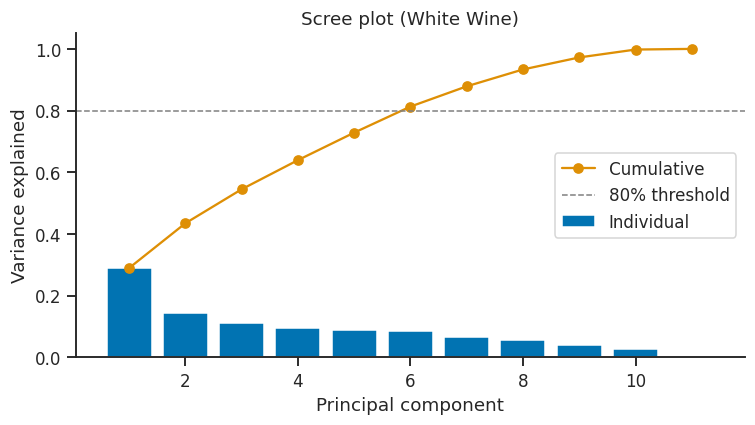

In [162]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks
fig, ax = plt.subplots(figsize=(7, 4))
n_show = 11
ax.bar(range(1, n_show+1), pca_sklearn_white.explained_variance_ratio_[:n_show],
       color=sns.color_palette('colorblind')[0], label='Individual')
ax.plot(range(1, n_show+1), np.cumsum(pca_sklearn_white.explained_variance_ratio_[:n_show]),
        'o-', color=sns.color_palette('colorblind')[1], label='Cumulative')
ax.axhline(0.80, color='gray', ls='--', lw=1, label='80% threshold')
ax.set_xlabel('Principal component'); ax.set_ylabel('Variance explained')
ax.set_title('Scree plot (White Wine)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

                       PC1   PC2
alcohol              -0.43  0.05
pH                   -0.11 -0.58
volatile acidity      0.03 -0.06
sulphates             0.05 -0.19
citric acid           0.15  0.38
fixed acidity         0.15  0.60
chlorides             0.21  0.03
free sulfur dioxide   0.31 -0.26
residual sugar        0.42 -0.02
total sulfur dioxide  0.42 -0.23
density               0.51 -0.01


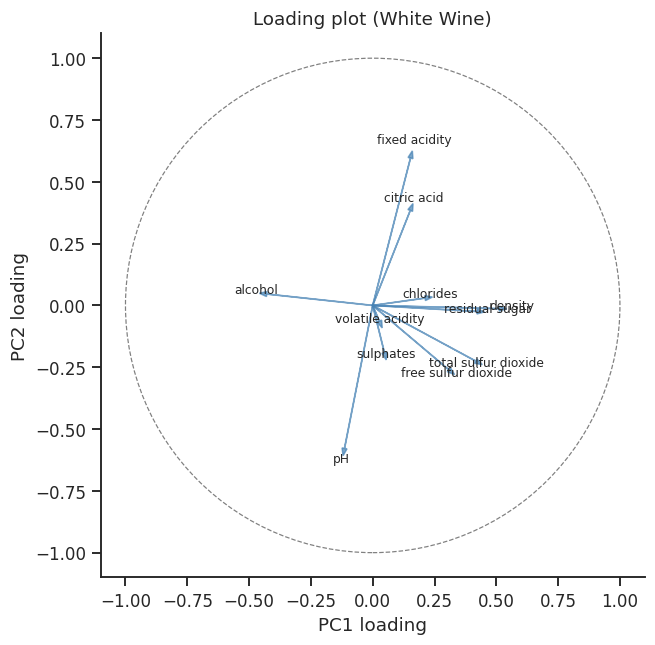

In [163]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?
loadings_df_white = pd.DataFrame(pca_sklearn_white.components_[:2].T, index=x_white.columns,
                            columns=['PC1', 'PC2'])
print(loadings_df_white.round(2).sort_values('PC1'))

fig, ax = plt.subplots(figsize=(7, 6))
for var_name in x_white.columns:
    x_coord, y_coord = loadings_df_white.loc[var_name, 'PC1'], loadings_df_white.loc[var_name, 'PC2']
    ax.arrow(0, 0, x_coord, y_coord, head_width=0.02, color='steelblue', alpha=0.7)
    ax.text(x_coord*1.1, y_coord*1.1, var_name, fontsize=8, ha='center')
circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', lw=0.8)
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1 loading'); ax.set_ylabel('PC2 loading')
ax.set_aspect('equal')
ax.set_title('Loading plot (White Wine)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [165]:
# TODO: redo ONE of your two Step 3 models (PLS or LDA -- your choice) on
# white wine, same methodology as before. Compare validated performance and
# top variables to your red-wine result (Checkpoint 3a/3b/3d) -- write the
# comparison on the answer sheet (Checkpoint 4b).
X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(x_white, y_white, test_size=0.25, random_state=0)
print(f'Train: {X_train_white.shape[0]} spectra, Test: {X_test_white.shape[0]} spectra')

Train: 2970 spectra, Test: 991 spectra


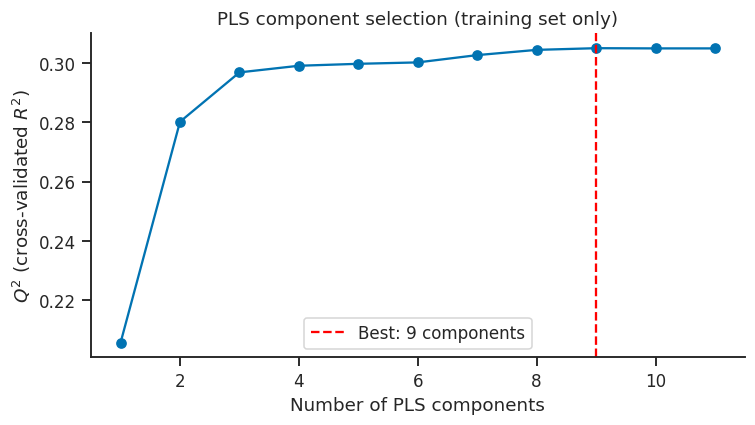

Selected 9 PLS components (Q2=0.305)


In [166]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone
kf = KFold(n_splits=10, shuffle=True, random_state=1)
max_components = 11
q2_scores_white = []
for nc in range(1, max_components + 1):
    pls = PLSRegression(n_components=nc, scale=True)
    y_cv_white = cross_val_predict(pls, X_train_white, y_train_white, cv=kf).ravel()
    q2_scores_white.append(r2_score(y_train_white, y_cv_white))

best_nc_white = np.argmax(q2_scores_red) + 1
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, max_components+1), q2_scores_white, 'o-', color=sns.color_palette('colorblind')[0])
ax.axvline(best_nc_white, color='red', ls='--', label=f'Best: {best_nc_white} components')
ax.set_xlabel('Number of PLS components'); ax.set_ylabel('$Q^2$ (cross-validated $R^2$)')
ax.set_title('PLS component selection (training set only)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
print(f'Selected {best_nc_white} PLS components (Q2={q2_scores_white[best_nc_white-1]:.3f})')

PLS test-set R2:   0.249
PLS test-set RMSE: 0.764 mS/cm


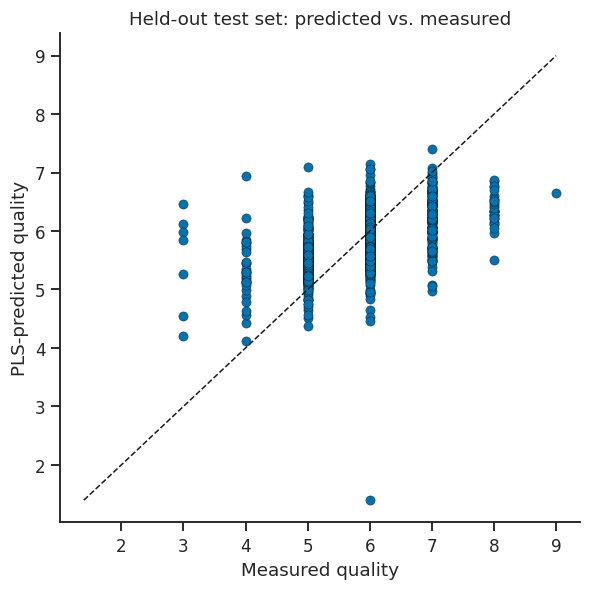

In [171]:
# TODO: report test-set RMSE and/or R^2, and a predicted-vs-observed plot
# (include the y=x identity line for reference)
pls_final_white = PLSRegression(n_components=best_nc_white, scale=True).fit(X_train_white, y_train_white)
y_pred_test_white = pls_final_white.predict(X_test_white).ravel()
r2_test_white = r2_score(y_test_white, y_pred_test_white)
rmse_test_white = np.sqrt(mean_squared_error(y_test_white, y_pred_test_white))
print(f'PLS test-set R2:   {r2_test_white:.3f}')
print(f'PLS test-set RMSE: {rmse_test_white:.3f} mS/cm')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test_white, y_pred_test_white, color=sns.color_palette('colorblind')[0], edgecolor='k', linewidth=0.3)
lims_white = [min(y_test_white.min(), y_pred_test_white.min()), max(y_test_white.max(), y_pred_test_white.max())]
ax.plot(lims_white, lims_white, 'k--', lw=1)
ax.set_xlabel('Measured quality'); ax.set_ylabel('PLS-predicted quality')
ax.set_title('Held-out test set: predicted vs. measured')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# Does your chosen model's validated performance and its most important variables (Checkpoint 3a/3b/3d) transfer to white wine, or not?
# Report the white-wine numbers alongside the red-wine ones for direct comparison.


In [177]:
print(f"PLS test-set R2 (Red Wine):   {r2_test_red:.3f}")
print(f"PLS test-set RMSE (Red Wine): {rmse_test_red:.3f}")

print(f"PLS test-set R2 (White Wine):   {r2_test_white:.3f}")
print(f"PLS test-set RMSE (White Wine): {rmse_test_white:.3f}")

PLS test-set R2 (Red Wine):   0.259
PLS test-set RMSE (Red Wine): 0.724
PLS test-set R2 (White Wine):   0.249
PLS test-set RMSE (White Wine): 0.764


In [174]:
print("\nTop PLS variables (Red Wine):")
print(pls_top_red.head(10).to_string(index=False))

print("\nTop PLS variables (White Wine):")
print(pls_top_white.head(10).to_string(index=False))


Top PLS variables (Red Wine):
            Variable   Loading
           sulphates  0.979822
             alcohol  0.312729
      residual sugar  0.036912
       fixed acidity  0.029164
 free sulfur dioxide  0.001785
total sulfur dioxide -0.002551
         citric acid -0.395201
                  pH -0.525678
    volatile acidity -1.077342
           chlorides -1.947465

Top PLS variables (White Wine):
            Variable   Loading
                  pH  0.965789
           sulphates  0.757979
         citric acid  0.294987
             alcohol  0.140497
       fixed acidity  0.097675
      residual sugar  0.090682
           chlorides  0.073411
 free sulfur dioxide  0.004741
total sulfur dioxide -0.000142
    volatile acidity -1.672788


---
## Wrap-up (3:45–4:00)

- [ ] Finalise your answer sheet (Checkpoints 1a–4b)

Hand in **this notebook** + your **answer sheet** — no separate report.